In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_hermite, gammaln

from core.IntensityModes import laguerre_gauss as Lg
from core.IntensityModes import hermite_gauss as Hg, hermite_gauss_1d as Hg_1d
from core.Polarization_elements import polarizers,scalar_to_vector, filter_polarizer,q_plate as qp
from core.masks import turbulence_mask as turb
from core.metrics import intensity as I, power as pwr, phase as phi, inner_product as dp
from core.Optical_elements import angular_spectrum as angSpec, tilt, mirror,beam_splitter as bs, lens

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from PIL import Image

from tqdm import trange

In [3]:
n = 2000
dx = 1e-3
x = np.linspace(-1e-2,1e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)



0.5000000000000744 0.5000000000000744
234184.72006333384
2.4384696654106264e-166
0.5000000000000744


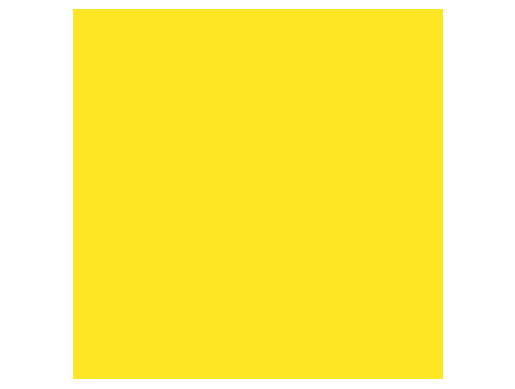

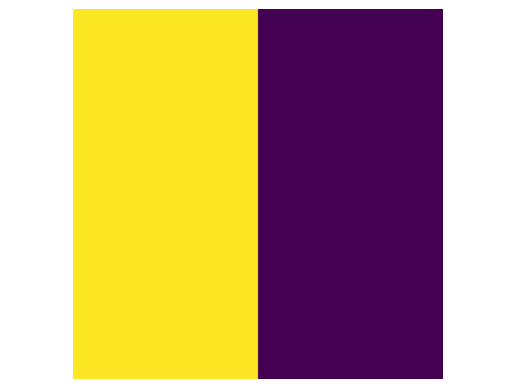

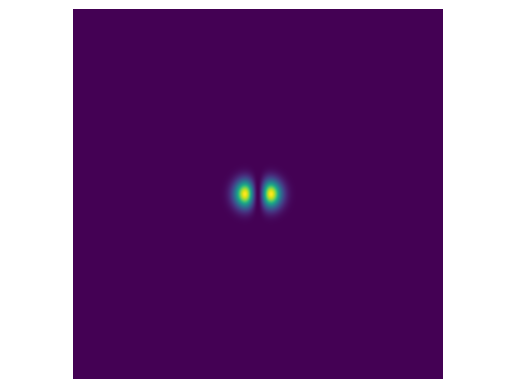

In [4]:
n = 2000
dx = 1e-3
x = np.linspace(-1e-2,1e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)

hg = Hg(x, y, 1)
arm1,arm2 = bs(hg)
print(pwr(x,y,arm1), pwr(x,y,arm2))
I(phi(arm2))
I(phi(arm1))
I(arm2)

print(np.max(np.abs(arm2)**2))
print(np.min(np.abs(arm2)**2))
print(pwr(x,y,arm2))

1.000000000000148


(<Figure size 640x480 with 1 Axes>, <Axes: >)

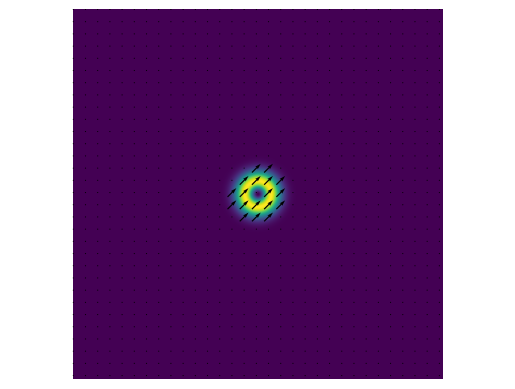

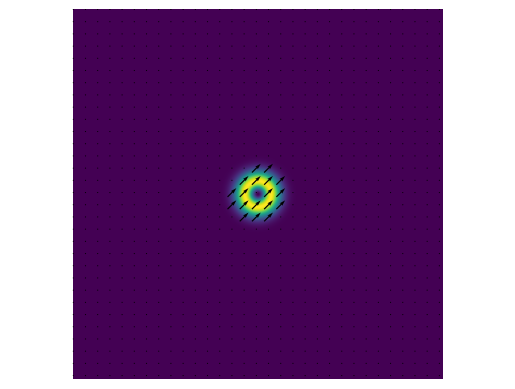

In [30]:
n = 2000
dx = 1e-3
x = np.linspace(-1e-2,1e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)

lg = Lg(x, y, 1)
lg = scalar_to_vector(lg,(1,1))

I(mirror(lg,theta=np.pi/2,rs=1j))
print(pwr(x,y,mirror(lg,theta=np.pi/2,rs=1j)))
I(((lg)))

(<Figure size 640x480 with 1 Axes>, <Axes: >)

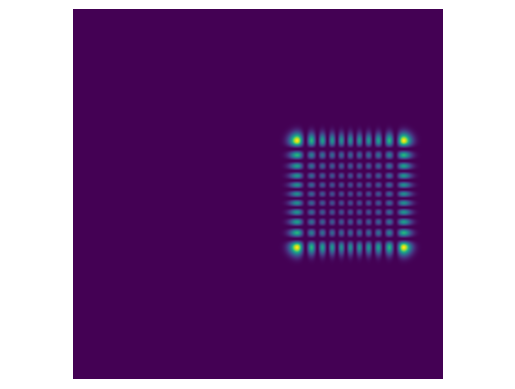

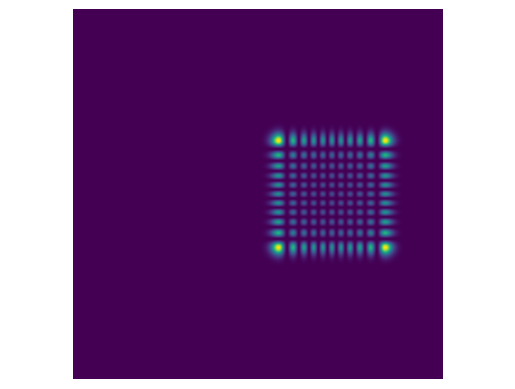

In [3]:
n = 2000
x = np.linspace(-1.5e-2,.5e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)
z1 = 0.2
hg = Hg(x, y, 10, 10)
I(hg)
hg = np.roll(hg,-100)
I(hg)

1.246081328418216


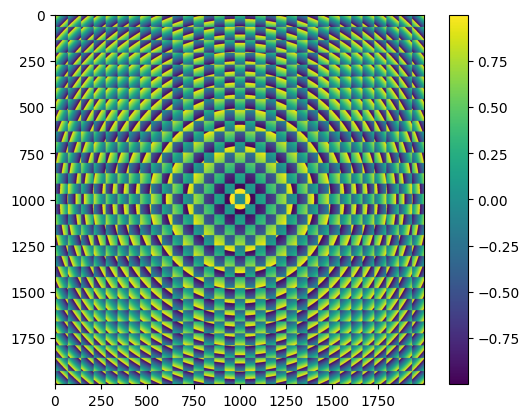

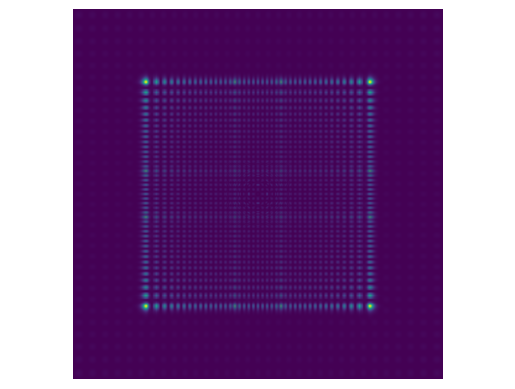

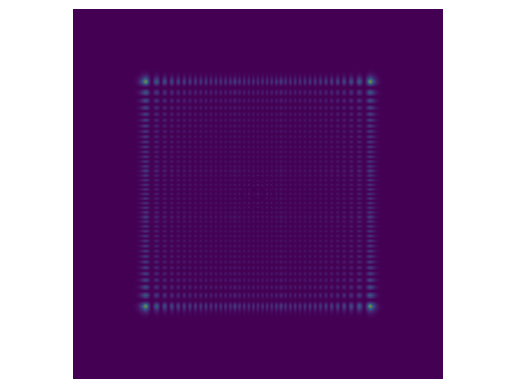

In [95]:
n = 2000
x = np.linspace(-1e-2,1e-2,n)
y = np.linspace(-1e-2,1e-2,n)
x,y = np.meshgrid(x,y)
z1 = 0.2
hg = Hg(x, y, 40, 40)
hg1 = Hg(x, y, 40, 40,z=10)
hg2 = angSpec(angSpec(lens(hg, x, y, f=z1), x, y, z=z1),x, y, z=z1)
print(pwr(x,y,hg1+hg2))

plt.imshow(phi(hg1)/np.pi)
plt.colorbar()
I(hg1 + hg2)
I(hg-hg2)
plt.show()

In [87]:
phi(hg1)[1000,1000]/np.pi

np.float64(0.7312448657031599)

1.0000000000001479
0.5000000000000742
0.5000000000000742
0.9999999999999115


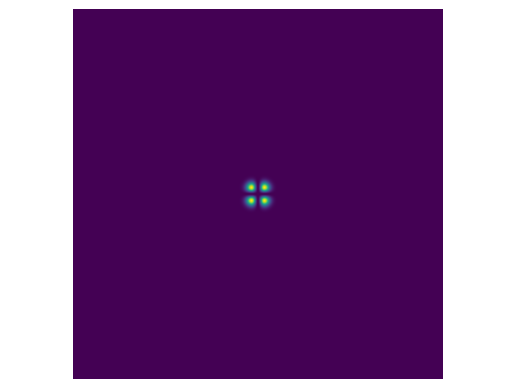

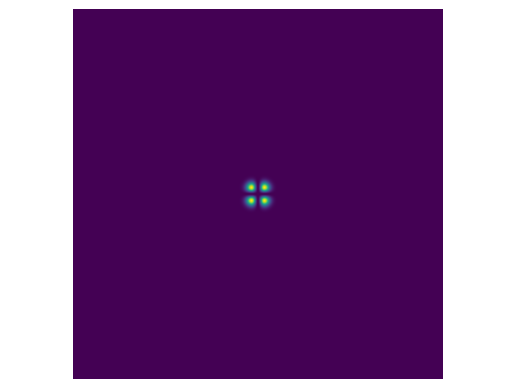

In [2]:
# creating the space
x = np.linspace(-2e-2,2e-2,2000)
y = np.linspace(-2e-2,2e-2,2000)
x,y = np.meshgrid(x,y)

hg = Hg(x, y, 1, 1)
print(pwr(x,y,hg))
hg1,hg2 = bs(hg)
I(hg1+hg2)
I(hg2)
hg_n = hg1 + tilt(hg2, x, y, safe=False, thetax=np.pi/4)
print(pwr(x,y,hg1))
print(pwr(x,y,hg2))
print(pwr(x,y,hg_n))

0.5000000000000739
0.5000000000000739
1.0000000000001479
0.0
1.0000000000001479 1.0000000000001479 1.0000000000001479


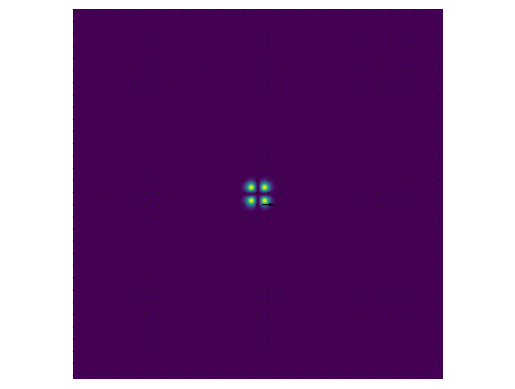

In [12]:
# creating the space
x = np.linspace(-2e-2,2e-2,2000)
y = np.linspace(-2e-2,2e-2,2000)
x,y = np.meshgrid(x,y)
theta = 0.0005
hg = Hg(x, y, 1, 1)
hg = scalar_to_vector(hg,(1,1))
field_back = mirror(hg, x, y, theta=theta,phi=0,rs=-1,rp=1j)
hg_n = hg + field_back
I(hg_n)
print(pwr(x,y,filter_polarizer(field_back,-45,'linear')))
print(pwr(x,y,filter_polarizer(field_back,45,'linear')))
print(pwr(x,y,filter_polarizer(field_back,0,'Rcirc')))
print(pwr(x,y,filter_polarizer(field_back,0,'Lcirc')))
print(pwr(x,y,hg),
pwr(x,y,field_back),
pwr(x,y,hg_n))


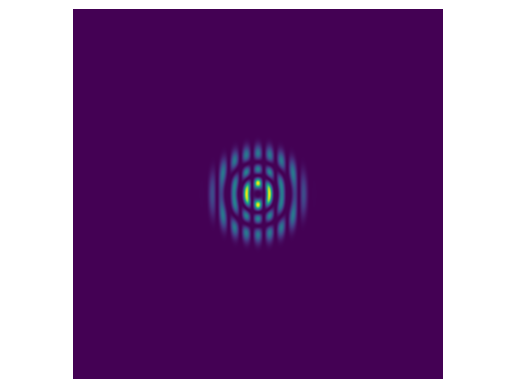

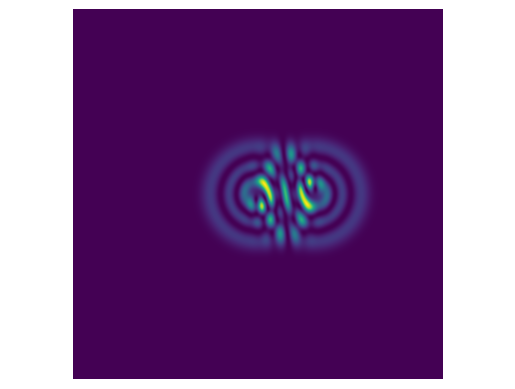

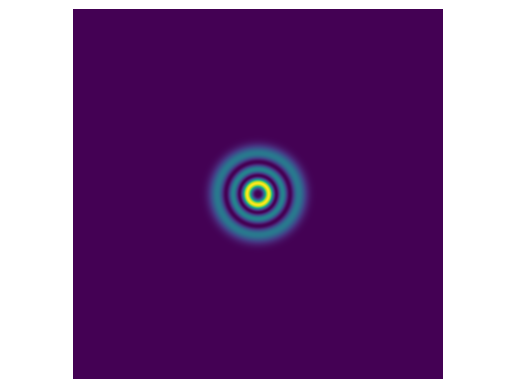

In [3]:
# creating the space
x = np.linspace(-1e-2,1e-2,1000)
y = np.linspace(-1e-2,1e-2,1000)
x,y = np.meshgrid(x,y)

# creating the intensity profile (2-dimensional)
lg = Lg(x,y,2,2)
# ploting (comparing the analitical and the simulated propagation)
I(lg_n := lg+tilt(lg,x,y,.001))
I(angSpec(lg_n,x,y,3))
I(lg)
plt.show()

0.9999999999999487
0.9999999999999487
1.1368683772161603e-13


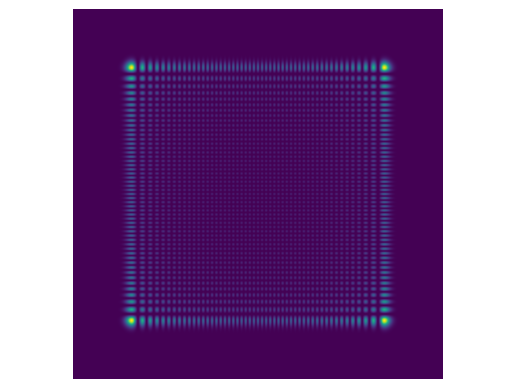

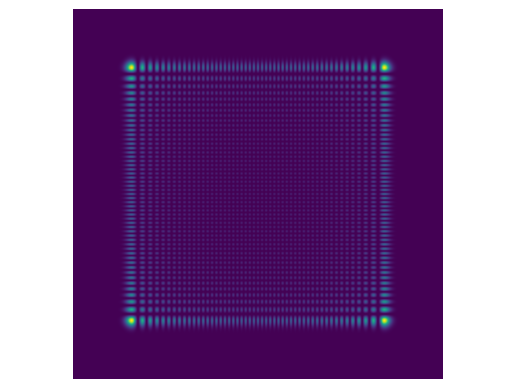

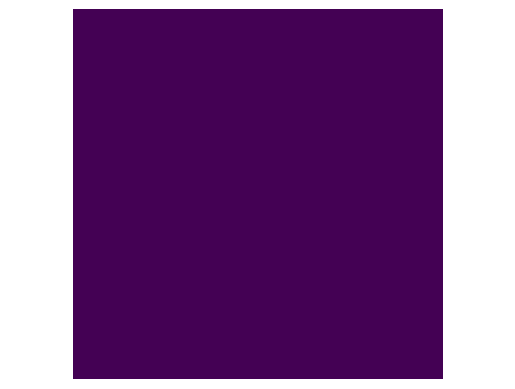

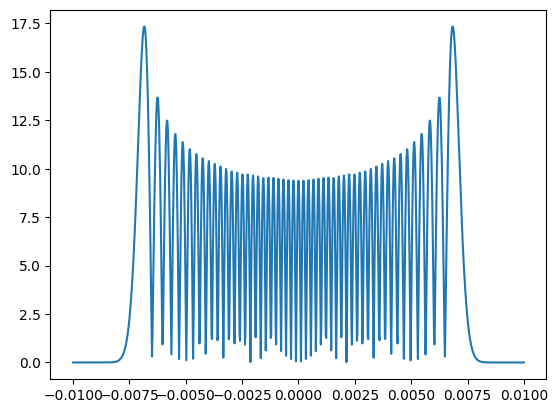

In [4]:
# creating the space
x = np.linspace(-1e-2,1e-2,1000)
y = np.linspace(-1e-2,1e-2,1000)
x,y = np.meshgrid(x,y)

# creating the intensity profile (2-dimensional)
mn = 50
hg = Hg(x,y,mn,mn)
hg1d = Hg_1d(x[0, :],mn)
I(hg)
print(pwr(x,y,hg))
I(hg_n := np.outer(hg1d,hg1d))
print(pwr(x,y,hg_n))
I(hg-hg_n)
print(np.max(np.abs(hg_n - hg)))
plt.show()
plt.plot(x[0, :], np.abs(hg1d))
plt.show()